In [51]:
#created on 17/04/2026 by James McLoughlin

In [15]:
from pathlib import Path
import earthaccess
import rasterio as rio
from rasterio.mask import mask
from rasterio.plot import show
import geopandas as gpd
import matplotlib.pyplot as plt
import shapely
#import pandas as pd

In [3]:
def get_satellite_bands(folder, bands):
#    satellite = parse_usgs_filename(filename)
    satellite = folder.split("_")[0]  # LC08
    if satellite == "LC08":      
        mapping = {
            "BLUE":"B2",
            "GREEN": "B3",
            "RED": "B4",
            "NIR":"B5",
           }
    elif satellite == "LC05":
        mapping = {
            "BLUE":"B1",
            "GREEN":"B2",
            "RED":"B3",
            "NIR":"B4",
            "SWIR1":"B5",
            "SWIR2":"B6",
        }
    return [mapping[b] for b in bands]

In [4]:
def clipping(datafile):
    for file in parent.rglob(datafile):
        print(file)
        with rio.open(file) as data:
            geom = [feature["geometry"] for feature in boundary.__geo_interface__["features"]]
            out_image, out_transform = mask(data, geom, crop=True)
            fig, ax2 = plt.subplots(figsize=(10, 10))
            show(out_image, ax=ax2)

In [203]:
#def parse_usgs_filename(filename):
#    parts = filename.split("_")
#    satellite = parts[0]  # LC08
#    pathrow = parts[2]
#    date_raw = parts[3]  # 20130815
#    return(satellite)

In [5]:
parent = Path("C:/RS_GIS/EGM722/Assignment/Test Data")
dataset = {}

for subfolder in parent.iterdir():
    if subfolder.is_dir() and not subfolder.name.endswith(".tar") and "AOI" not in subfolder.name:
        files = [f.name for f in subfolder.glob("*_SR_B*.TIF")]
        dataset[subfolder.name] = files

#for folder, files in dataset.items():
#    print(folder)
#    for f in files:
#        print(f"  {f}")
#    print()
folders = list(dataset.keys())

In [2]:
earthaccess.login(strategy='netrc')

In [26]:
EADatasets = earthaccess.search_datasets(keyword="Landsat Thematic Mapper Collection 2 Level-2 Surface Reflectance")
len(EADatasets)

3

In [27]:
for d in EADatasets:
    print(d["umm"]["ShortName"])
    print(d["umm"]["EntryTitle"])
    print("-"*60)

Landsat Level-2 Surface Reflectance Collection 2
Landsat Level-2 Surface Reflectance Collection 2
------------------------------------------------------------
landsat-2
Landsat Collection 2 - Level-2
------------------------------------------------------------
LANDSAT-16D-1
Landsat Collection 2 - Level-2 - Data Cube - LCF 16 days
------------------------------------------------------------


<function matplotlib.pyplot.show(close=None, block=None)>

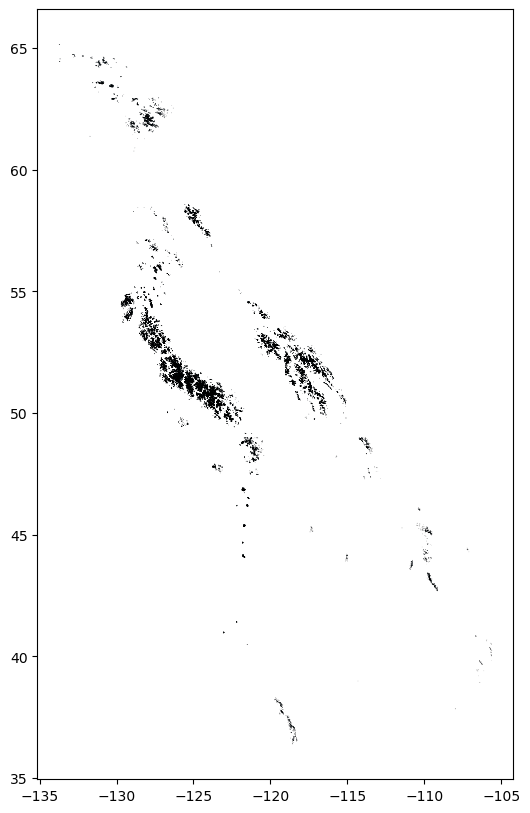

In [3]:
rgi = gpd.read_file("C:/RS_GIS/EGM722/Assignment/nsidc0770_02.rgi60.WesternCanadaUS/02_rgi60_WesternCanadaUS.shp")
fig, ax3 = plt.subplots(figsize=(10, 10))
rgi.plot(ax=ax3,edgecolor="black", linewidth=0.3)
plt.show

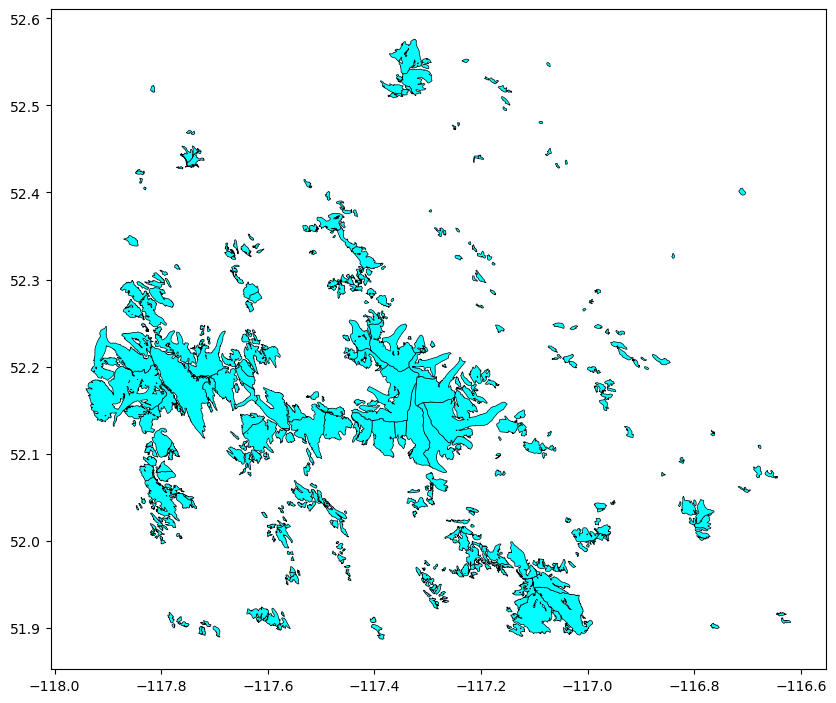

In [4]:
icefield = rgi.cx[-117.85:-116.60, 51.90:52.55]


fig, ax = plt.subplots(figsize=(10, 10))

icefield.plot(
    ax=ax,
    color="cyan",
    edgecolor="black",
    linewidth=0.5
)

plt.show()

In [138]:
boundary = gpd.read_file("C:/Users/jj_mc/OneDrive/Documents/GitHub/EGM722-Assessment/columbia_icefield.shp").to_crs(epsg=4326)

In [139]:
boundary.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [140]:
outline = boundary['geometry'].union_all()

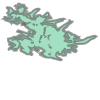

In [141]:
outline

In [142]:
outline.bounds

(-117.45747800030944, 52.078005000430494, -117.1508959995507, 52.2653170003793)

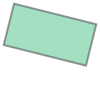

In [143]:
search_area = outline.minimum_rotated_rectangle
search_area

In [144]:
search_area.bounds

(-117.4807525655258, 52.04717162110035, -117.14033050834539, 52.27490165801565)

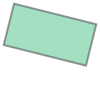

In [145]:
search_area = shapely.geometry.polygon.orient(search_area, sign=1)
search_area

In [146]:
earthaccess.login(strategy='netrc')

In [ ]:
bounding_box = (-114.0, 31.33, -108.0, 49.01)

In [147]:
short_list = ["LANDSAT_SURFACE_REFLECTANCE_L4-5_TM","Landsat Level-2 Surface Reflectance Collection 2","Landsat_8","landsat-2","LANDSAT_SURFACE_REFLECTANCE_L7_ETM"]
EAdata = earthaccess.search_data(
    short_name = short_list,
    temporal = ("1985-01-01","2025-12-31"),
    polygon = search_area.exterior.coords
)
len(EAdata)

0

In [135]:
# This will list available collections matching 'Landsat 5'
collections = earthaccess.search_datasets(
    keyword="surface reflectance",
    polygon = search_area.exterior.coords
)
for c in collections:
    print(c["umm"]["ShortName"])

MOD09GQ
MYD09GQ
MYD09GA
MOD09GA
HLSL30
HLSS30
MOD09A1
MOD09Q1
MYD09Q1
VNP09
MYD09A1
EMITL2ARFL
VNP09GA
VNP09A1
MOD09
AST_07XT
VNP09H1
AST_07
PACE_OCI_L2_SFREFL
MOD09CMG
PACE_OCI_L2_SFREFL_NRT
VJ109GA
MYD09CMG
VJ109A1
VNP09CMG
MCD19A1CMGL
PACE_OCI_L3M_SFREFL
VJ109CMG
VJ109H1
S3B_SY_2_SYN
VJ109
M1_AVH09C1
PACE_OCI_L3B_SFREFL
VJ209CMG
VJ209GA
MOD09
S3A_SY_2_SYN
MOD09
GFCC30SR
N16_AVH09C1
MCD19A1CMGO
MOD09A1N
MOD09A1N
MOD09CMG
MOD09CMG
MOD09GA
MOD09GA
MOD09GHK
MOD09GHK
MOD09GQ
MOD09GQ
MOD09GQK
MOD09GQK
MOD09GST
MOD09GST
MOD09Q1N
MYD09CMG
MYD09CMG
MYD09GA
MYD09GA
MYD09GHK
MYD09GHK
MYD09GQ
MYD09GQ
MYD09GQK
MYD09GQK
MYD09GST
MYD09GST
N14_AVH09C1
PACE_OCI_L3B_SFREFL
PACE_OCI_L3B_SFREFL_NRT
PACE_OCI_L3B_SFREFL_NRT
PACE_OCI_L3M_SFREFL
PACE_OCI_L3M_SFREFL_NRT
PACE_OCI_L3M_SFREFL_NRT
VCD19A1CMG
VJ209A1
VJ209H1
AV3_L2A_RFL_2357
AVIRIS-NG_L2_Reflectance_2110
Landsat Level-2 Surface Reflectance Collection 2
MYD09
MYD09
MYD09
PACE_OCI_L2_SFREFL
PACE_OCI_L2_SFREFL_NRT
VJ109CMG_NRT
VJ109GA_NRT
VJ109_NRT